In [829]:

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import root_mean_squared_error
from sklearn.feature_selection import VarianceThreshold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

from xgboost import XGBRegressor as xgb


import matplotlib.pyplot as plt


In [830]:
%run ./ml_model_init.ipynb

## Data


In [891]:

xg_data= data[(data['minutes_5'] >= 300) & (data['position'] != 'GK')][['position', 'minutes_3', 'minutes_5', 'team_h_difficulty', 'team_a_difficulty', 'ict_index_3',  'ict_index_5',
                                                                     'influence_3', 'influence_5', 'creativity_3', 'creativity_5', 'threat_3', 'threat_5', 'was_home', 'xG', 'xG_3',
                                                                      'expected_goals_conceded_3', 'expected_goals_conceded_5', 'xG_5', 'expected_goals_3', 'expected_goals_5',
                                                                      'goals_scored_3', 'whh', 'whd', 'wha']]

xg_data_tar = data_tar[(data_tar['minutes_5'] >= 300) & (data_tar['position'] != 'GK')][['position', 'minutes_3', 'minutes_5', 'team_h_difficulty', 'team_a_difficulty', 'ict_index_3',  'ict_index_5',
                                                                     'influence_3', 'influence_5', 'creativity_3', 'creativity_5', 'threat_3', 'threat_5', 'was_home', 'xG', 'xG_3',
                                                                     'expected_goals_conceded_3', 'expected_goals_conceded_5', 'xG_5', 'expected_goals_3', 'expected_goals_5',
                                                                     'goals_scored_3', 'whh', 'whd', 'wha']]


In [892]:
xg_data = xg_data.dropna()
xg = xg_data[['xG']]
feats = xg_data.drop('xG', axis=1)


# position = feats['position']
OHE = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = OHE.fit_transform(feats[['position', 'was_home']])
print(OHE.categories_)

one_hot_df = pd.DataFrame(encoded,  columns=OHE.get_feature_names_out(['position', 'was_home']))

feats_ = feats.drop(['position', 'was_home'], axis=1).reset_index().drop('index', axis=1)

feats_sklearn_encoded = pd.concat([feats_, one_hot_df], axis=1)
# feats_sklearn_encoded

scaler = StandardScaler()

scaled = scaler.fit_transform(feats_sklearn_encoded)
feats_sklearn_enc_scaled = pd.DataFrame(scaled, columns=[feats_sklearn_encoded.columns])

[array(['DEF', 'FWD', 'MID'], dtype=object), array([False,  True])]


In [894]:
# feats = feats[feats['position'].notnull()]
feats_train, feats_test, xg_train, xg_test = train_test_split(feats_sklearn_enc_scaled, xg , test_size=0.2, random_state=42)


## Baseline Model


#### Linear Model


In [895]:

lin_reg = Linear_regression(feats_train, feats_test, xg_train, xg_test)

# Store the model evaluation details in a DataFrame
evaluation_stats = pd.DataFrame({"lin_reg": [lin_reg['train_MAE'], lin_reg['test_MAE'], lin_reg['train_RMSE'], lin_reg['test_RMSE'], lin_reg['cv_rmse'], lin_reg['R2_train'], lin_reg['R2_test']]},
                                                        index=(['train_MAE','test_MAE', 'train_RMSE', 'test_RMSE', 'cv_rmse', 'R2_train', 'R2_test']))

evaluation_stats

Training set RMSE: 0.2437293900191867
Test set RMSE: 0.2519354819160331
Training set R2: 0.22400356629409124
Test set R2: 0.19741436026946702


,lin_reg
train_MAE,0.145072
test_MAE,0.146538
train_RMSE,0.243729
test_RMSE,0.251935
cv_rmse,0.244838
R2_train,0.224004
R2_test,0.197414


#### DecisionTree Model


In [896]:
dt_reg = DecisionTreeRegression(feats_train, feats_test, xg_train, xg_test)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(dt_reg = [dt_reg['train_MAE'], dt_reg['test_MAE'], dt_reg['train_RMSE'], dt_reg['test_RMSE'], dt_reg['cv_rmse'], dt_reg['R2_train'], dt_reg['R2_test']])

evaluation_stats



,lin_reg,dt_reg
train_MAE,0.145072,0.000000
test_MAE,0.146538,0.185523
train_RMSE,0.243729,0.000000
test_RMSE,0.251935,0.344920
cv_rmse,0.244838,0.357626
R2_train,0.224004,1.000000
R2_test,0.197414,-0.504349


#### RandomForest Model


In [897]:
hyperparameters = {"criterion": 'friedman_mse', "max_depth": 8, "max_features": 'sqrt', "n_estimators": 20}
rf_reg = RandomForestRegression(feats_train, feats_test, xg_train.values.ravel(), xg_test.values.ravel(), hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(rf_reg = [rf_reg['train_MAE'], rf_reg['test_MAE'], rf_reg['train_RMSE'], rf_reg['test_RMSE'], rf_reg['cv_rmse'], rf_reg['R2_train'], rf_reg['R2_test']])

evaluation_stats

,lin_reg,dt_reg,rf_reg
train_MAE,0.145072,0.000000,0.127392
test_MAE,0.146538,0.185523,0.148653
train_RMSE,0.243729,0.000000,0.204981
test_RMSE,0.251935,0.344920,0.254871
cv_rmse,0.244838,0.357626,0.248181
R2_train,0.224004,1.000000,0.451126
R2_test,0.197414,-0.504349,0.178599


#### XgBoost Model


In [898]:
hyperparameters = {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150}
xgb_reg = XGBoostRegression(feats_train, feats_test, xg_train, xg_test, hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(xgb_reg = [xgb_reg['train_MAE'], xgb_reg['test_MAE'], xgb_reg['train_RMSE'], xgb_reg['test_RMSE'], xgb_reg['cv_rmse'], xgb_reg['R2_train'], xgb_reg['R2_test']])
evaluation_stats

,lin_reg,dt_reg,rf_reg,xgb_reg
train_MAE,0.145072,0.000000,0.127392,0.138177
test_MAE,0.146538,0.185523,0.148653,0.146175
train_RMSE,0.243729,0.000000,0.204981,0.227173
test_RMSE,0.251935,0.344920,0.254871,0.249545
cv_rmse,0.244838,0.357626,0.248181,0.244738
R2_train,0.224004,1.000000,0.451126,0.325851
R2_test,0.197414,-0.504349,0.178599,0.212572


### AdaBoost


In [899]:
hyperparameters = {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150}
ada_reg = XGBoostRegression(feats_train, feats_test, xg_train, xg_test, hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(ada_reg = [ada_reg['train_MAE'], ada_reg['test_MAE'], ada_reg['train_RMSE'], ada_reg['test_RMSE'], ada_reg['cv_rmse'], ada_reg['R2_train'], ada_reg['R2_test']])
evaluation_stats

,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg
train_MAE,0.145072,0.000000,0.127392,0.138177,0.138177
test_MAE,0.146538,0.185523,0.148653,0.146175,0.146175
train_RMSE,0.243729,0.000000,0.204981,0.227173,0.227173
test_RMSE,0.251935,0.344920,0.254871,0.249545,0.249545
cv_rmse,0.244838,0.357626,0.248181,0.244738,0.244738
R2_train,0.224004,1.000000,0.451126,0.325851,0.325851
R2_test,0.197414,-0.504349,0.178599,0.212572,0.212572


# Feature engineering


### Data


In [836]:
cols_ = ['position', 'team_h_difficulty', 'team_a_difficulty', 'value', 'was_home','xG', 'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3', 'xP_3', 'selected_3', 'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5', 'xP_5', 'selected_5', 'whh', 'whd', 'wha']

working_data = data[cols_]
# working_tar = working_tar.drop(['fpl_id', 'understat_id', 'event'], axis=1)
# working_tar_cols = working_tar.columns.tolist()
working_data = working_data.fillna(0)
working_data = working_data[working_data['position'] !=0]
working_data


,position,team_h_difficulty,team_a_difficulty,value,was_home,xG,clean_sheets_3,expected_assists_3,expected_goal_involvements_3,expected_goals_3,...,key_passes_5,npg_5,npxG_5,xGChain_5,xGBuildup_5,xP_5,selected_5,whh,whd,wha
0,DEF,5.0,3.0,5.0,True,0.000000,0.0,0.00,0.00,0.00,...,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.105,0.188,0.707
1,DEF,2.0,2.0,5.0,False,0.054937,0.0,0.10,0.10,0.00,...,1.0,0.0,0.00,0.00,0.00,1.3,266706.0,0.224,0.268,0.508
2,DEF,3.0,3.0,5.0,True,0.063659,0.0,0.31,0.36,0.05,...,6.0,0.0,0.05,0.33,0.29,3.3,587596.0,0.419,0.277,0.304
3,DEF,2.0,2.0,5.0,False,0.062027,0.0,0.64,0.74,0.10,...,8.0,0.0,0.12,0.40,0.35,4.3,894938.0,0.419,0.277,0.304
4,DEF,3.0,3.0,4.9,True,0.000000,1.0,0.55,0.70,0.15,...,8.0,0.0,0.18,0.46,0.42,6.5,1152571.0,0.255,0.262,0.483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8824,MID,2.0,3.0,7.8,False,1.524264,1.0,0.96,2.79,1.83,...,13.0,2.0,1.44,5.51,1.98,25.3,16957336.0,0.464,0.264,0.272
8825,MID,3.0,3.0,7.9,True,0.224260,0.0,0.51,2.19,1.68,...,13.0,2.0,2.17,6.09,2.01,27.5,17470889.0,0.449,0.236,0.315
8826,MID,2.0,2.0,7.9,False,0.375406,0.0,0.52,2.11,1.59,...,13.0,1.0,2.26,6.43,2.21,25.2,18297047.0,0.393,0.270,0.337
8827,MID,2.0,2.0,7.9,False,0.375406,0.0,0.52,2.11,1.59,...,13.0,1.0,2.26,6.43,2.21,25.2,18297047.0,0.393,0.270,0.337


In [837]:
xg_data_ = working_data[(working_data['minutes_5'] >= 300) & (working_data['position'] != 'GK')]
xg_data_ = xg_data_.dropna()


# position = feats['position']
OHE_ = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_ = OHE_.fit_transform(xg_data_[['position', 'was_home']])
# print(OHE_.categories_)

one_hot_df = pd.DataFrame(encoded_,  columns=OHE_.get_feature_names_out(['position', 'was_home']))

feats__ = xg_data_.drop(['position', 'was_home'], axis=1).reset_index().drop('index', axis=1)


# Separate numerical features (excluding 'position' before encoding)
scaler = StandardScaler()

scaled = scaler.fit_transform(feats__)
feats_sklearn_enc_scaled_ = pd.DataFrame(scaled, columns=scaler.get_feature_names_out(feats__.columns))
# feats_sklearn_enc_scaled_

# Concatenate scaled numerical features with the one-hot encoded position features
feats_sklearn_enc_scaled_ = pd.concat([feats_sklearn_enc_scaled_, one_hot_df], axis=1)

xg_ = feats_sklearn_enc_scaled_[['xG']]
feats_ = feats_sklearn_enc_scaled_.drop('xG', axis=1)

In [838]:
feats_train, feats_test, xg_train, xg_test = train_test_split(feats_, xg_ , test_size=0.2, random_state=42)

## SelectFromModel


In [839]:
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor as xgb
from sklearn.feature_selection import SelectFromModel

rf_hyperparameters = {"criterion": 'friedman_mse', "max_depth": 8, "max_features": 'sqrt', "n_estimators": 20}
xg_hyperparameters = {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150}
print(feats_train.shape)
lin_model = LinearRegression()
dt_model = DecisionTreeRegressor()
extr_model = ExtraTreesRegressor(random_state=18)
rf_model = RandomForestRegressor(random_state=18)
xg_model = model = xgb(learning_rate=xg_hyperparameters["learning_rate"],
                    n_estimators=xg_hyperparameters["n_estimators"],
                    max_depth=xg_hyperparameters["max_depth"],
                    eval_metric='rmsle')

ada_model = AdaBoostRegressor(random_state=18)


lin_model = lin_model.fit(feats_train, xg_train.values.ravel())
dt_model = dt_model.fit(feats_train, xg_train.values.ravel())
extr_model = extr_model.fit(feats_train, xg_train.values.ravel())
rf_model = rf_model.fit(feats_train, xg_train.values.ravel())
xg_model = xg_model.fit(feats_train, xg_train.values.ravel())
ada_model = ada_model.fit(feats_train, xg_train.values.ravel())

# clf = clf.fit(feats_train, xg_train.values.ravel())
# print(clf.feature_importances_ )

lin_selector = SelectFromModel(lin_model ,prefit=True)
dt_selector = SelectFromModel(dt_model ,prefit=True)
extr_selector = SelectFromModel(extr_model ,prefit=True)
rf_selector = SelectFromModel(rf_model,prefit=True)
xg_selector = SelectFromModel(xg_model ,prefit=True)
ada_selector = SelectFromModel(ada_model ,prefit=True)


(8826, 79)


In [840]:

SelectFromModel_cols_lin = list(feats_train.columns[lin_selector.get_support()])
SelectFromModel_cols_dt = list(feats_train.columns[dt_selector.get_support()])
SelectFromModel_cols_rf = list(feats_train.columns[rf_selector.get_support()])
SelectFromModel_cols_extr = list(feats_train.columns[extr_selector.get_support()])
SelectFromModel_cols_xg = list(feats_train.columns[xg_selector.get_support()])
SelectFromModel_cols_ada = list(feats_train.columns[ada_selector.get_support()])

feats_train_SFM_lin, feats_test_SFM_lin, xg_train_SFM_lin, xg_test_SFM_lin = train_test_split(feats_[SelectFromModel_cols_lin], xg_ , test_size=0.2, random_state=42)
feats_train_SFM_dt, feats_test_SFM_dt, xg_train_SFM_dt, xg_test_SFM_dt = train_test_split(feats_[SelectFromModel_cols_dt], xg_ , test_size=0.2, random_state=42)
feats_train_SFM_rf, feats_test_SFM_rf, xg_train_SFM_rf, xg_test_SFM_rf = train_test_split(feats_[SelectFromModel_cols_rf], xg_ , test_size=0.2, random_state=42)
feats_train_SFM_extr, feats_test_SFM_extr, xg_train_SFM_extr, xg_test_SFM_extr = train_test_split(feats_[SelectFromModel_cols_extr], xg_ , test_size=0.2, random_state=42)
feats_train_SFM_xg, feats_test_SFM_xg, xg_train_SFM_xg, xg_test_SFM_xg = train_test_split(feats_[SelectFromModel_cols_xg], xg_ , test_size=0.2, random_state=42)
feats_train_SFM_ada, feats_test_SFM_ada, xg_train_SFM_ada, xg_test_SFM_ada = train_test_split(feats_[SelectFromModel_cols_ada], xg_ , test_size=0.2, random_state=42)


#### Feature Importance


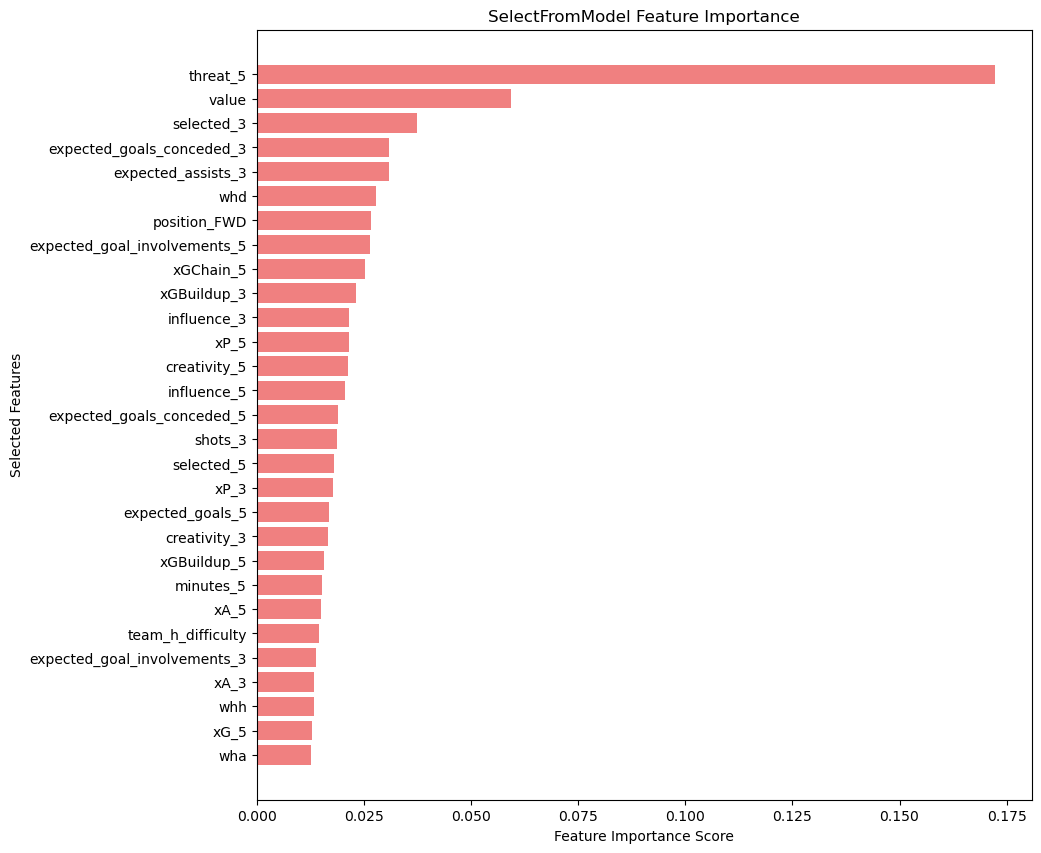

In [841]:
# Feature selection using SelectFromModel
selected_features_mask = dt_selector.get_support()
selected_feature_names = feats_.columns[selected_features_mask]

# Get feature importances
feature_importances = dt_model.feature_importances_[selected_features_mask]

# Sort features by importance
sorted_indices = np.argsort(feature_importances)[::-1]  # Sort descending
sorted_features = np.array(selected_feature_names)[sorted_indices]
sorted_importances = feature_importances[sorted_indices]

# Plot feature importance
plt.figure(figsize=(10, 10))
plt.barh(sorted_features, sorted_importances, color='lightcoral')
plt.xlabel("Feature Importance Score")
plt.ylabel("Selected Features")
plt.title("SelectFromModel Feature Importance")
plt.gca().invert_yaxis()  # Show most important feature on top
plt.show()


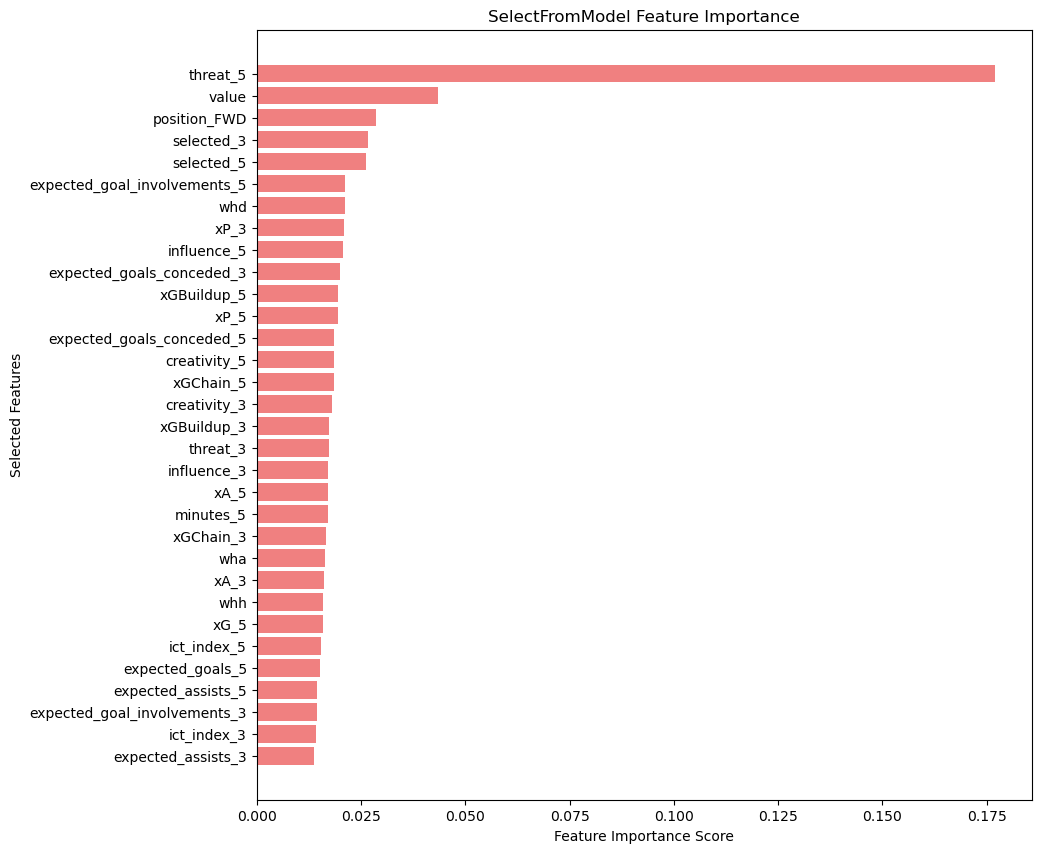

In [842]:
# Feature selection using SelectFromModel
selected_features_mask = rf_selector.get_support()
selected_feature_names = feats_.columns[selected_features_mask]

# Get feature importances
feature_importances = rf_model.feature_importances_[selected_features_mask]

# Sort features by importance
sorted_indices = np.argsort(feature_importances)[::-1]  # Sort descending
sorted_features = np.array(selected_feature_names)[sorted_indices]
sorted_importances = feature_importances[sorted_indices]

# Plot feature importance
plt.figure(figsize=(10, 10))
plt.barh(sorted_features, sorted_importances, color='lightcoral')
plt.xlabel("Feature Importance Score")
plt.ylabel("Selected Features")
plt.title("SelectFromModel Feature Importance")
plt.gca().invert_yaxis()  # Show most important feature on top
plt.show()

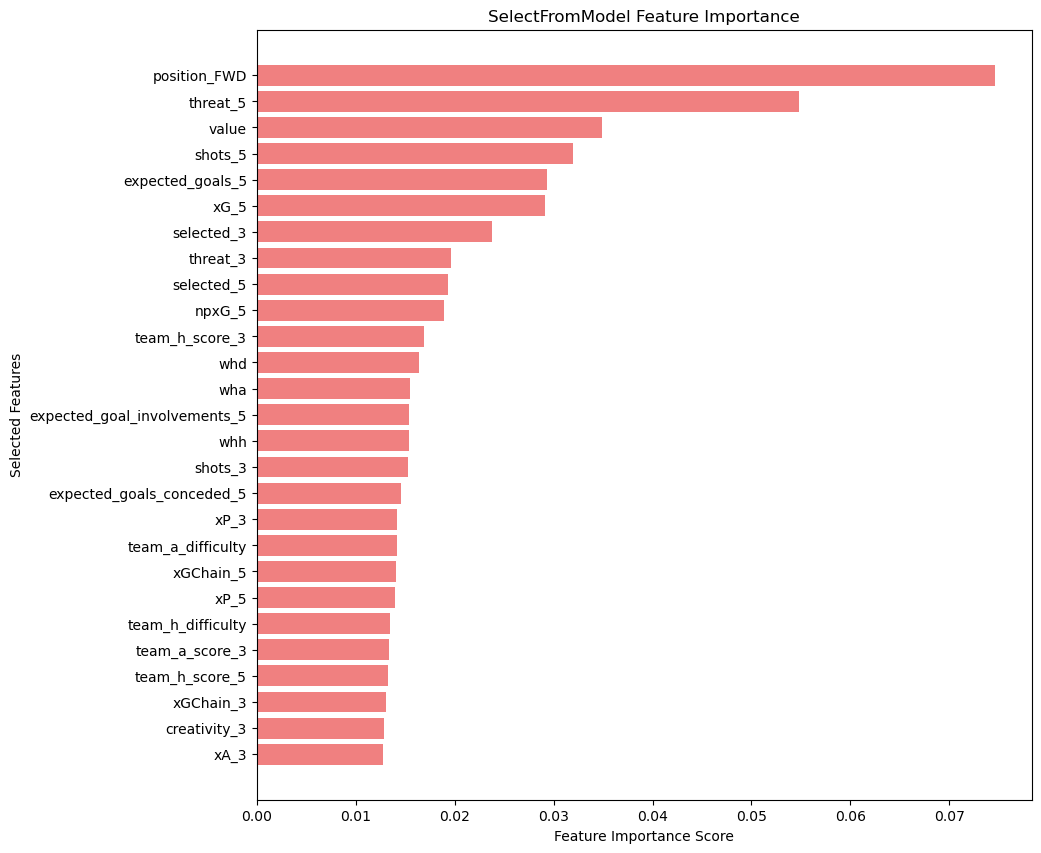

In [843]:
# Feature selection using SelectFromModel
selected_features_mask = extr_selector.get_support()
selected_feature_names = feats_.columns[selected_features_mask]

# Get feature importances
feature_importances = extr_model.feature_importances_[selected_features_mask]

# Sort features by importance
sorted_indices = np.argsort(feature_importances)[::-1]  # Sort descending
sorted_features = np.array(selected_feature_names)[sorted_indices]
sorted_importances = feature_importances[sorted_indices]

# Plot feature importance
plt.figure(figsize=(10, 10))
plt.barh(sorted_features, sorted_importances, color='lightcoral')
plt.xlabel("Feature Importance Score")
plt.ylabel("Selected Features")
plt.title("SelectFromModel Feature Importance")
plt.gca().invert_yaxis()  # Show most important feature on top
plt.show()

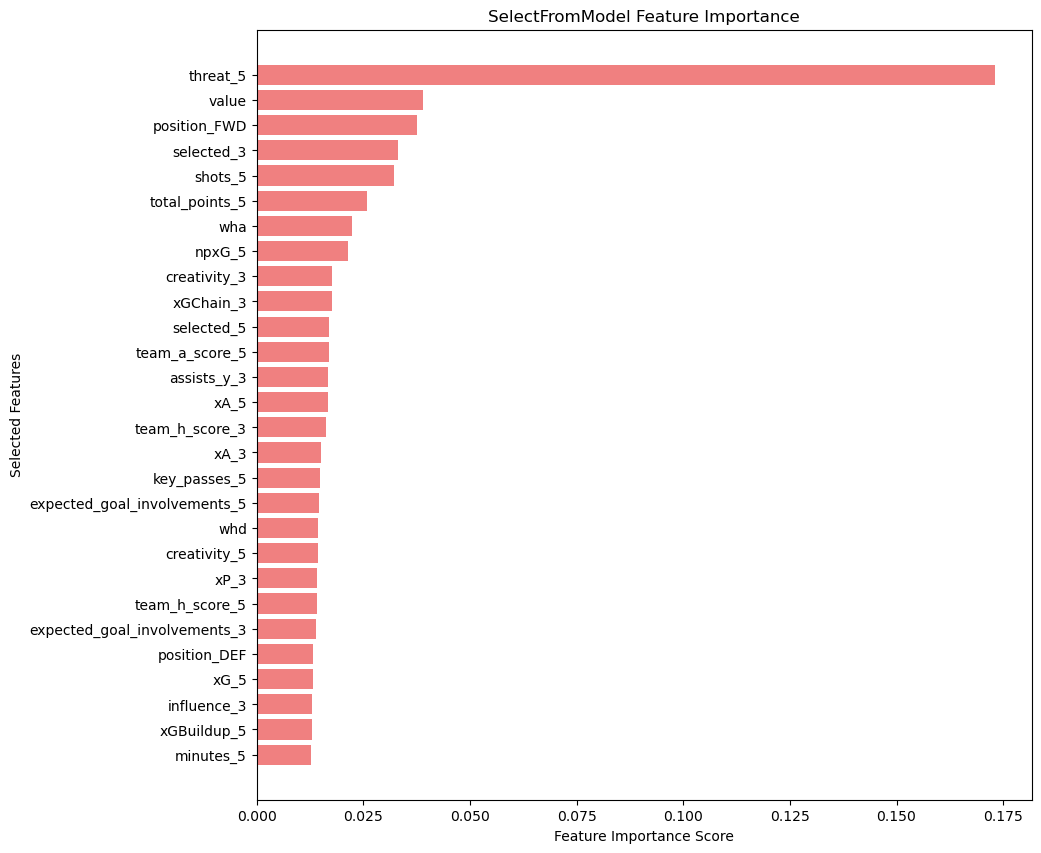

In [844]:
# Feature selection using SelectFromModel
selected_features_mask = xg_selector.get_support()
selected_feature_names = feats_.columns[selected_features_mask]

# Get feature importances
feature_importances = xg_model.feature_importances_[selected_features_mask]

# Sort features by importance
sorted_indices = np.argsort(feature_importances)[::-1]  # Sort descending
sorted_features = np.array(selected_feature_names)[sorted_indices]
sorted_importances = feature_importances[sorted_indices]

# Plot feature importance
plt.figure(figsize=(10, 10))
plt.barh(sorted_features, sorted_importances, color='lightcoral')
plt.xlabel("Feature Importance Score")
plt.ylabel("Selected Features")
plt.title("SelectFromModel Feature Importance")
plt.gca().invert_yaxis()  # Show most important feature on top
plt.show()

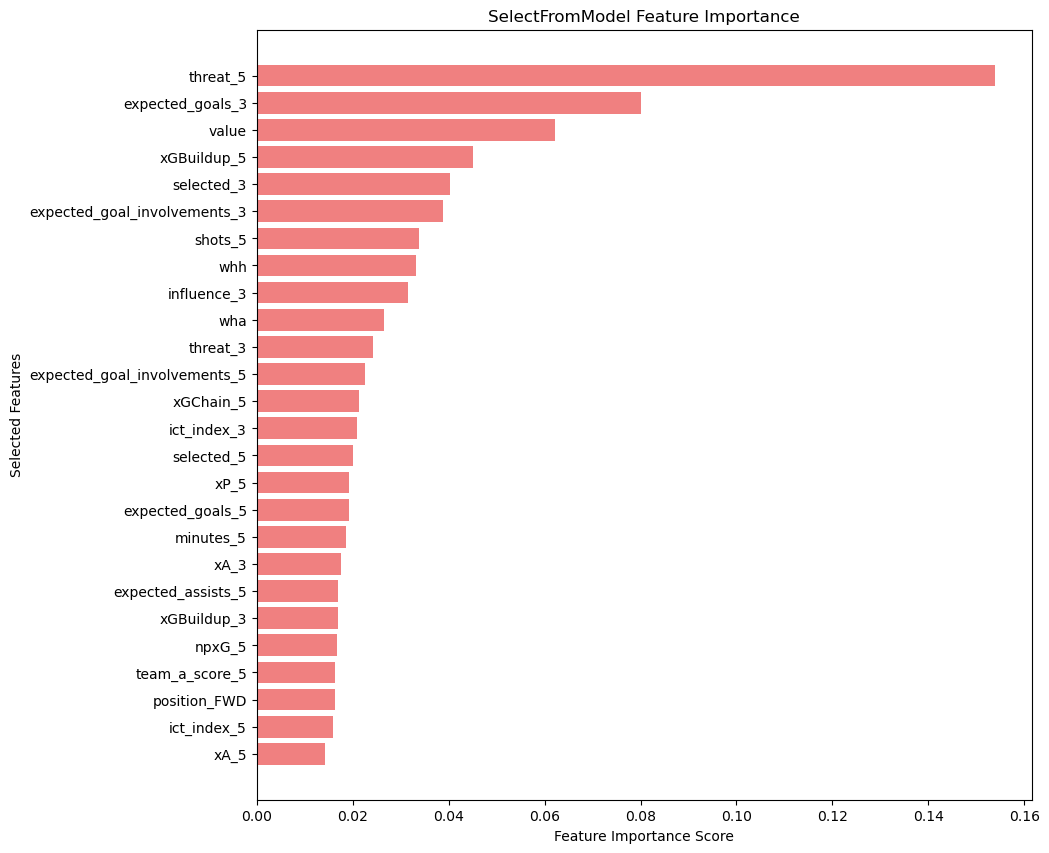

In [845]:
# Feature selection using SelectFromModel
selected_features_mask = ada_selector.get_support()
selected_feature_names = feats_.columns[selected_features_mask]

# Get feature importances
feature_importances = ada_model.feature_importances_[selected_features_mask]

# Sort features by importance
sorted_indices = np.argsort(feature_importances)[::-1]  # Sort descending
sorted_features = np.array(selected_feature_names)[sorted_indices]
sorted_importances = feature_importances[sorted_indices]

# Plot feature importance
plt.figure(figsize=(10, 10))
plt.barh(sorted_features, sorted_importances, color='lightcoral')
plt.xlabel("Feature Importance Score")
plt.ylabel("Selected Features")
plt.title("SelectFromModel Feature Importance")
plt.gca().invert_yaxis()  # Show most important feature on top
plt.show()

#### Linear Model


In [846]:

lin_reg_SFM = Linear_regression(feats_train_SFM_lin, feats_test_SFM_lin, xg_train_SFM_lin, xg_test_SFM_lin)

# lin_reg_SFM
# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(lin_reg_SFM = [lin_reg_SFM['train_MAE'], lin_reg_SFM['test_MAE'], lin_reg_SFM['train_RMSE'], lin_reg_SFM['test_RMSE'], lin_reg_SFM['cv_rmse'], lin_reg_SFM['R2_train'], lin_reg_SFM['R2_test']])
evaluation_stats

Training set RMSE: 0.9056267323154531
Test set RMSE: 0.8988538182610559
Training set R2: 0.19219314381665265
Test set R2: 0.13932914279950548


,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM
train_MAE,0.516671,3.158588e-17,0.445971,0.490059,0.490059,0.545233
test_MAE,0.515621,6.512310e-01,0.513642,0.511282,0.511282,0.534540
train_RMSE,0.867664,6.015365e-17,0.715031,0.801809,0.801809,0.905627
test_RMSE,0.873449,1.212852e+00,0.877233,0.864707,0.864707,0.898854
cv_rmse,0.881455,1.286536e+00,0.893087,0.879876,0.879876,0.906434
R2_train,0.258497,1.000000e+00,0.496431,0.366786,0.366786,0.192193
R2_test,0.187294,-5.670197e-01,0.180236,0.203479,0.203479,0.139329


#### DecisionTree Model


In [847]:
dt_reg_SFM = DecisionTreeRegression(feats_train_SFM_dt, feats_test_SFM_dt, xg_train_SFM_dt, xg_test_SFM_dt)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(dt_reg_SFM = [dt_reg_SFM['train_MAE'], dt_reg_SFM['test_MAE'], dt_reg_SFM['train_RMSE'], dt_reg_SFM['test_RMSE'], dt_reg_SFM['cv_rmse'], dt_reg_SFM['R2_train'], dt_reg_SFM['R2_test']])

evaluation_stats



,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM
train_MAE,0.516671,3.158588e-17,0.445971,0.490059,0.490059,0.545233,3.254189e-17
test_MAE,0.515621,6.512310e-01,0.513642,0.511282,0.511282,0.534540,6.780511e-01
train_RMSE,0.867664,6.015365e-17,0.715031,0.801809,0.801809,0.905627,6.102949e-17
test_RMSE,0.873449,1.212852e+00,0.877233,0.864707,0.864707,0.898854,1.238312e+00
cv_rmse,0.881455,1.286536e+00,0.893087,0.879876,0.879876,0.906434,1.250642e+00
R2_train,0.258497,1.000000e+00,0.496431,0.366786,0.366786,0.192193,1.000000e+00
R2_test,0.187294,-5.670197e-01,0.180236,0.203479,0.203479,0.139329,-6.334997e-01


### RandomForest


In [848]:
hyperparameters = {"criterion": 'friedman_mse', "max_depth": 8, "max_features": 'sqrt', "n_estimators": 20}
rf_reg_SFM = RandomForestRegression(feats_train_SFM_rf, feats_test_SFM_rf, xg_train_SFM_rf.values.ravel(), xg_test_SFM_rf.values.ravel(), hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(rf_reg_SFM = [rf_reg_SFM['train_MAE'], rf_reg_SFM['test_MAE'], rf_reg_SFM['train_RMSE'], rf_reg_SFM['test_RMSE'], rf_reg_SFM['cv_rmse'], rf_reg_SFM['R2_train'], rf_reg_SFM['R2_test']])

evaluation_stats

,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM
train_MAE,0.516671,3.158588e-17,0.445971,0.490059,0.490059,0.545233,3.254189e-17,0.447282
test_MAE,0.515621,6.512310e-01,0.513642,0.511282,0.511282,0.534540,6.780511e-01,0.514367
train_RMSE,0.867664,6.015365e-17,0.715031,0.801809,0.801809,0.905627,6.102949e-17,0.718174
test_RMSE,0.873449,1.212852e+00,0.877233,0.864707,0.864707,0.898854,1.238312e+00,0.878753
cv_rmse,0.881455,1.286536e+00,0.893087,0.879876,0.879876,0.906434,1.250642e+00,0.891802
R2_train,0.258497,1.000000e+00,0.496431,0.366786,0.366786,0.192193,1.000000e+00,0.491994
R2_test,0.187294,-5.670197e-01,0.180236,0.203479,0.203479,0.139329,-6.334997e-01,0.177393


### XgBoost


In [849]:
hyperparameters = {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150}
xgb_reg_SFM = XGBoostRegression(feats_train_SFM_xg, feats_test_SFM_xg, xg_train_SFM_xg.values.ravel(), xg_test_SFM_xg.values.ravel(), hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(xgb_reg_SFM = [xgb_reg_SFM['train_MAE'], xgb_reg_SFM['test_MAE'], xgb_reg_SFM['train_RMSE'], xgb_reg_SFM['test_RMSE'], xgb_reg_SFM['cv_rmse'], xgb_reg_SFM['R2_train'], xgb_reg_SFM['R2_test']])
evaluation_stats

,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM
train_MAE,0.516671,3.158588e-17,0.445971,0.490059,0.490059,0.545233,3.254189e-17,0.447282,0.494053
test_MAE,0.515621,6.512310e-01,0.513642,0.511282,0.511282,0.534540,6.780511e-01,0.514367,0.514809
train_RMSE,0.867664,6.015365e-17,0.715031,0.801809,0.801809,0.905627,6.102949e-17,0.718174,0.810789
test_RMSE,0.873449,1.212852e+00,0.877233,0.864707,0.864707,0.898854,1.238312e+00,0.878753,0.868901
cv_rmse,0.881455,1.286536e+00,0.893087,0.879876,0.879876,0.906434,1.250642e+00,0.891802,0.882911
R2_train,0.258497,1.000000e+00,0.496431,0.366786,0.366786,0.192193,1.000000e+00,0.491994,0.352522
R2_test,0.187294,-5.670197e-01,0.180236,0.203479,0.203479,0.139329,-6.334997e-01,0.177393,0.195735


### AdaBoost


In [850]:
hyperparameters = {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150}
ada_reg_SFM = XGBoostRegression(feats_train_SFM_ada, feats_test_SFM_ada, xg_train_SFM_ada.values.ravel(), xg_test_SFM_ada.values.ravel(), hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(ada_reg_SFM = [ada_reg_SFM['train_MAE'], ada_reg_SFM['test_MAE'], ada_reg_SFM['train_RMSE'], ada_reg_SFM['test_RMSE'], ada_reg_SFM['cv_rmse'], ada_reg_SFM['R2_train'], ada_reg_SFM['R2_test']])
evaluation_stats

,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM
train_MAE,0.516671,3.158588e-17,0.445971,0.490059,0.490059,0.545233,3.254189e-17,0.447282,0.494053,0.498303
test_MAE,0.515621,6.512310e-01,0.513642,0.511282,0.511282,0.534540,6.780511e-01,0.514367,0.514809,0.512716
train_RMSE,0.867664,6.015365e-17,0.715031,0.801809,0.801809,0.905627,6.102949e-17,0.718174,0.810789,0.816534
test_RMSE,0.873449,1.212852e+00,0.877233,0.864707,0.864707,0.898854,1.238312e+00,0.878753,0.868901,0.867860
cv_rmse,0.881455,1.286536e+00,0.893087,0.879876,0.879876,0.906434,1.250642e+00,0.891802,0.882911,0.888489
R2_train,0.258497,1.000000e+00,0.496431,0.366786,0.366786,0.192193,1.000000e+00,0.491994,0.352522,0.343314
R2_test,0.187294,-5.670197e-01,0.180236,0.203479,0.203479,0.139329,-6.334997e-01,0.177393,0.195735,0.197661


## VarianceThreshold


In [851]:
from sklearn.compose import TransformedTargetRegressor, ColumnTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import pandas as pd

# Feature preprocessing pipeline
# Split into numerical and categorical columns
bool_cols = feats_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = feats_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Preprocessing for numerical features
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Preprocessing for categorical features
categorical_transformer = Pipeline(steps=[
    ('one_hot_encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessors in a column transformer
col_trans = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, bool_cols),
        ('cat', categorical_transformer, categorical_cols),
    ]
)

# Scale and remove low-variance features
preprocessor = Pipeline(steps=[
    ('col_trans', col_trans),
    ('var_threshold', VarianceThreshold(threshold=0.1))
])

# Apply the pipeline to the training data
# pipeline.fit(feats_train)
# preprocessed_train = pipeline.transform(feats_train)
# preprocessed_test = pipeline.transform(feats_test)


# preprocessor = Pipeline(steps=[
#     ('scaler', StandardScaler()),
#     ('var_threshold', VarianceThreshold(threshold=0.1))
# ])




## Model(VT)


In [852]:
def scores(model, feats_train, feats_test, xg_train, xg_test):
    # fit the transofrmer on the train data
    model.fit(feats_train, xg_train)

    support = model.regressor_.named_steps['preprocessor'].named_steps['var_threshold'].get_support()
    # print(f"Selected features: {feats_train.columns[support]}")
    print(len(support), len(feats_train.columns))

    # With the model fitted, we can predict the total_points given the feature_train and feature_test set
    pred_train = model.predict(feats_train)
    pred_test = model.predict(feats_test)

    # Evaluate the performance of the model on both sets using the mean absolute error
    train_MAE = mean_absolute_error(xg_train, pred_train)
    test_MAE = mean_absolute_error(xg_test, pred_test)

    # Evaluate the performance of the model on both sets using the mean square error
    train_MSE = mean_squared_error(xg_train, pred_train)
    test_MSE = mean_squared_error(xg_test, pred_test)

    # Evaluate the performance of the model on both sets using the root mean square error
    train_RMSE = root_mean_squared_error(xg_train, pred_train)
    test_RMSE = root_mean_squared_error(xg_test, pred_test)

    # Get the score of the model or the coeeficient of determination i.e how much of the target value can be explained by the model.
    # In this case, 0.6 implies that 60% of the variations in the target value can be explained by the model and 40% is not explainable
    R2_train = model.score(feats_train, xg_train)
    R2_test = model.score(feats_test, xg_test)

    # If the test error significantly differs from the train error, then there is either overfitting or underfitting
    # RMSE, just like the squared loss function that it derives from, effectively penalizes larger errors more severely.
    print('Training set RMSE: {}'.format(train_RMSE))
    print('Test set RMSE: {}'.format(test_RMSE))

    print('Training set R2: {}'.format(R2_train))
    print('Test set R2: {}'.format(R2_test))

    # Carry out cross validation of the model.
    # The evaluation method is the root mean square error
    # The method expects a utility function (greater is better) and so the scoring function is the opposite of the the RMSE. Hence the -ve
    tree_rmses = -cross_val_score(model, feats_train, xg_train,
                                    scoring="neg_root_mean_squared_error", cv=10)

    return {'train_MAE': train_MAE, 'test_MAE': test_MAE, 'train_MSE': train_MSE, 'test_MSE': test_MSE, 'train_RMSE': train_RMSE, 'test_RMSE': test_RMSE, 'cv_rmse': tree_rmses.mean(), 'R2_train': R2_train, 'R2_test': R2_test}


##### Linear Model


In [853]:

# Full pipeline including the regression model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# TransformedTargetRegressor for target scaling
model = TransformedTargetRegressor(
    regressor=pipeline,
    transformer=StandardScaler()
)

# Model predictions
VarT_lin_reg = scores(model, feats_train, feats_test, xg_train.values.ravel(), xg_test.values.ravel())

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(VarT_lin_reg =  [VarT_lin_reg['train_MAE'], VarT_lin_reg['test_MAE'],  VarT_lin_reg['train_RMSE'], VarT_lin_reg['test_RMSE'], VarT_lin_reg['cv_rmse'], VarT_lin_reg['R2_train'], VarT_lin_reg['R2_test']])

evaluation_stats

79 79
Training set RMSE: 0.8701513153153136
Test set RMSE: 0.8783216554952595
Training set R2: 0.254240782697287
Test set R2: 0.1781999869294546


,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM,VarT_lin_reg
train_MAE,0.516671,3.158588e-17,0.445971,0.490059,0.490059,0.545233,3.254189e-17,0.447282,0.494053,0.498303,0.518709
test_MAE,0.515621,6.512310e-01,0.513642,0.511282,0.511282,0.534540,6.780511e-01,0.514367,0.514809,0.512716,0.518336
train_RMSE,0.867664,6.015365e-17,0.715031,0.801809,0.801809,0.905627,6.102949e-17,0.718174,0.810789,0.816534,0.870151
test_RMSE,0.873449,1.212852e+00,0.877233,0.864707,0.864707,0.898854,1.238312e+00,0.878753,0.868901,0.867860,0.878322
cv_rmse,0.881455,1.286536e+00,0.893087,0.879876,0.879876,0.906434,1.250642e+00,0.891802,0.882911,0.888489,0.882367
R2_train,0.258497,1.000000e+00,0.496431,0.366786,0.366786,0.192193,1.000000e+00,0.491994,0.352522,0.343314,0.254241
R2_test,0.187294,-5.670197e-01,0.180236,0.203479,0.203479,0.139329,-6.334997e-01,0.177393,0.195735,0.197661,0.178200


##### DecisionTree Model


In [854]:
# Full pipeline including the regression model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor())
])

# TransformedTargetRegressor for target scaling
dt_model = TransformedTargetRegressor(
    regressor=pipeline,
    transformer=StandardScaler()
)

VarT_dt_reg = scores(dt_model, feats_train, feats_test, xg_train.values.ravel(), xg_test.values.ravel())

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(VarT_dt_reg = [VarT_dt_reg['train_MAE'], VarT_dt_reg['test_MAE'], VarT_dt_reg['train_RMSE'], VarT_dt_reg['test_RMSE'], VarT_dt_reg['cv_rmse'], VarT_dt_reg['R2_train'], VarT_dt_reg['R2_test']])

evaluation_stats



79 79
Training set RMSE: 1.3978372193669008e-17
Test set RMSE: 1.2133796173030311
Training set R2: 1.0
Test set R2: -0.5683838191023891


,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM,VarT_lin_reg,VarT_dt_reg
train_MAE,0.516671,3.158588e-17,0.445971,0.490059,0.490059,0.545233,3.254189e-17,0.447282,0.494053,0.498303,0.518709,6.693219e-19
test_MAE,0.515621,6.512310e-01,0.513642,0.511282,0.511282,0.534540,6.780511e-01,0.514367,0.514809,0.512716,0.518336,6.602664e-01
train_RMSE,0.867664,6.015365e-17,0.715031,0.801809,0.801809,0.905627,6.102949e-17,0.718174,0.810789,0.816534,0.870151,1.397837e-17
test_RMSE,0.873449,1.212852e+00,0.877233,0.864707,0.864707,0.898854,1.238312e+00,0.878753,0.868901,0.867860,0.878322,1.213380e+00
cv_rmse,0.881455,1.286536e+00,0.893087,0.879876,0.879876,0.906434,1.250642e+00,0.891802,0.882911,0.888489,0.882367,1.272291e+00
R2_train,0.258497,1.000000e+00,0.496431,0.366786,0.366786,0.192193,1.000000e+00,0.491994,0.352522,0.343314,0.254241,1.000000e+00
R2_test,0.187294,-5.670197e-01,0.180236,0.203479,0.203479,0.139329,-6.334997e-01,0.177393,0.195735,0.197661,0.178200,-5.683838e-01


##### RandomForest Model


In [855]:
hyperparameters = {"criterion": 'friedman_mse', "max_depth": 8, "max_features": 'sqrt', "n_estimators": 20}

# Full pipeline including the regression model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
                        n_estimators=hyperparameters['n_estimators'],
                        max_depth=hyperparameters['max_depth'],
                        criterion=hyperparameters['criterion'], random_state=18
                        ))
])

# TransformedTargetRegressor for target scaling
rf_model = TransformedTargetRegressor(
    regressor=pipeline,
    transformer=StandardScaler()
)
# Store the model evaluation details in a DataFrame
VarT_rf_reg = scores(rf_model, feats_train, feats_test, xg_train, xg_test)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(VarT_rf_reg = [VarT_rf_reg['train_MAE'], VarT_rf_reg['test_MAE'], VarT_rf_reg['train_RMSE'], VarT_rf_reg['test_RMSE'], VarT_rf_reg['cv_rmse'], VarT_rf_reg['R2_train'], VarT_rf_reg['R2_test']])
evaluation_stats

79 79
Training set RMSE: 0.7155801205630454
Test set RMSE: 0.8795949636890845
Training set R2: 0.4956574595094184
Test set R2: 0.17581552293868885


,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM,VarT_lin_reg,VarT_dt_reg,VarT_rf_reg
train_MAE,0.516671,3.158588e-17,0.445971,0.490059,0.490059,0.545233,3.254189e-17,0.447282,0.494053,0.498303,0.518709,6.693219e-19,0.446287
test_MAE,0.515621,6.512310e-01,0.513642,0.511282,0.511282,0.534540,6.780511e-01,0.514367,0.514809,0.512716,0.518336,6.602664e-01,0.513976
train_RMSE,0.867664,6.015365e-17,0.715031,0.801809,0.801809,0.905627,6.102949e-17,0.718174,0.810789,0.816534,0.870151,1.397837e-17,0.715580
test_RMSE,0.873449,1.212852e+00,0.877233,0.864707,0.864707,0.898854,1.238312e+00,0.878753,0.868901,0.867860,0.878322,1.213380e+00,0.879595
cv_rmse,0.881455,1.286536e+00,0.893087,0.879876,0.879876,0.906434,1.250642e+00,0.891802,0.882911,0.888489,0.882367,1.272291e+00,0.893179
R2_train,0.258497,1.000000e+00,0.496431,0.366786,0.366786,0.192193,1.000000e+00,0.491994,0.352522,0.343314,0.254241,1.000000e+00,0.495657
R2_test,0.187294,-5.670197e-01,0.180236,0.203479,0.203479,0.139329,-6.334997e-01,0.177393,0.195735,0.197661,0.178200,-5.683838e-01,0.175816


##### XgBoost Model


In [856]:
hyperparameters = {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150}

# Full pipeline including the regression model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb(learning_rate=hyperparameters["learning_rate"],
                    n_estimators=hyperparameters["n_estimators"],
                    max_depth=hyperparameters["max_depth"],
                    eval_metric='rmsle'))
])

# TransformedTargetRegressor for target scaling
rf_model = TransformedTargetRegressor(
    regressor=pipeline,
    transformer=StandardScaler()
)

VarT_xgb_reg = scores(rf_model, feats_train, feats_test, xg_train, xg_test)



# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(VarT_xgb_reg = [VarT_xgb_reg['train_MAE'], VarT_xgb_reg['test_MAE'], VarT_xgb_reg['train_RMSE'], VarT_xgb_reg['test_RMSE'], VarT_xgb_reg['cv_rmse'], VarT_xgb_reg['R2_train'], VarT_xgb_reg['R2_test']])
evaluation_stats

79 79
Training set RMSE: 0.8018088050819947
Test set RMSE: 0.8647070698361541
Training set R2: 0.36678576469421387
Test set R2: 0.20347946882247925


,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM,VarT_lin_reg,VarT_dt_reg,VarT_rf_reg,VarT_xgb_reg
train_MAE,0.516671,3.158588e-17,0.445971,0.490059,0.490059,0.545233,3.254189e-17,0.447282,0.494053,0.498303,0.518709,6.693219e-19,0.446287,0.490059
test_MAE,0.515621,6.512310e-01,0.513642,0.511282,0.511282,0.534540,6.780511e-01,0.514367,0.514809,0.512716,0.518336,6.602664e-01,0.513976,0.511281
train_RMSE,0.867664,6.015365e-17,0.715031,0.801809,0.801809,0.905627,6.102949e-17,0.718174,0.810789,0.816534,0.870151,1.397837e-17,0.715580,0.801809
test_RMSE,0.873449,1.212852e+00,0.877233,0.864707,0.864707,0.898854,1.238312e+00,0.878753,0.868901,0.867860,0.878322,1.213380e+00,0.879595,0.864707
cv_rmse,0.881455,1.286536e+00,0.893087,0.879876,0.879876,0.906434,1.250642e+00,0.891802,0.882911,0.888489,0.882367,1.272291e+00,0.893179,0.879937
R2_train,0.258497,1.000000e+00,0.496431,0.366786,0.366786,0.192193,1.000000e+00,0.491994,0.352522,0.343314,0.254241,1.000000e+00,0.495657,0.366786
R2_test,0.187294,-5.670197e-01,0.180236,0.203479,0.203479,0.139329,-6.334997e-01,0.177393,0.195735,0.197661,0.178200,-5.683838e-01,0.175816,0.203479


## KBest


In [857]:
from sklearn.feature_selection import SelectKBest, mutual_info_regression

k_rf_model = RandomForestRegressor(n_estimators=20,  max_depth=8, criterion='friedman_mse', max_features='sqrt', random_state=18)

score_list  = []

for k in range(1, 21):
  selector = SelectKBest(mutual_info_regression, k=k)
  k_sel_X_train =  selector.fit_transform(feats_train, xg_train.values.ravel())

  k_rf_model.fit(k_sel_X_train, xg_train.values.ravel())

  k_sel_cols = feats_train.columns[selector.get_support()]
  k_sel_X_test = feats_test[k_sel_cols]
  score = round(k_rf_model.score(k_sel_X_test.values, xg_test ), 3)

  score_list.append(score)
print(score_list, score_list.index(max(score_list)))
num_of_feat = score_list.index(max(score_list)) # find the highest score. We will use  that as the value of k

selector = SelectKBest(mutual_info_regression, k=num_of_feat+1)
selector.fit_transform(feats_train, xg_train.values.ravel())

sel_feats = selector.get_feature_names_out()
# k_sel_X_train = feats_train[sel_feats]
# k_sel_X_test = feats_test[sel_feats]

feats_train_KBest, feats_test_KBest, xg_train_KBest, xg_test_KBest = train_test_split(feats_[sel_feats], xg_ , test_size=0.2, random_state=42)

[0.084, 0.14, 0.14, 0.179, 0.193, 0.155, 0.149, 0.181, 0.171, 0.173, 0.189, 0.171, 0.173, 0.189, 0.176, 0.179, 0.185, 0.18, 0.185, 0.187] 4


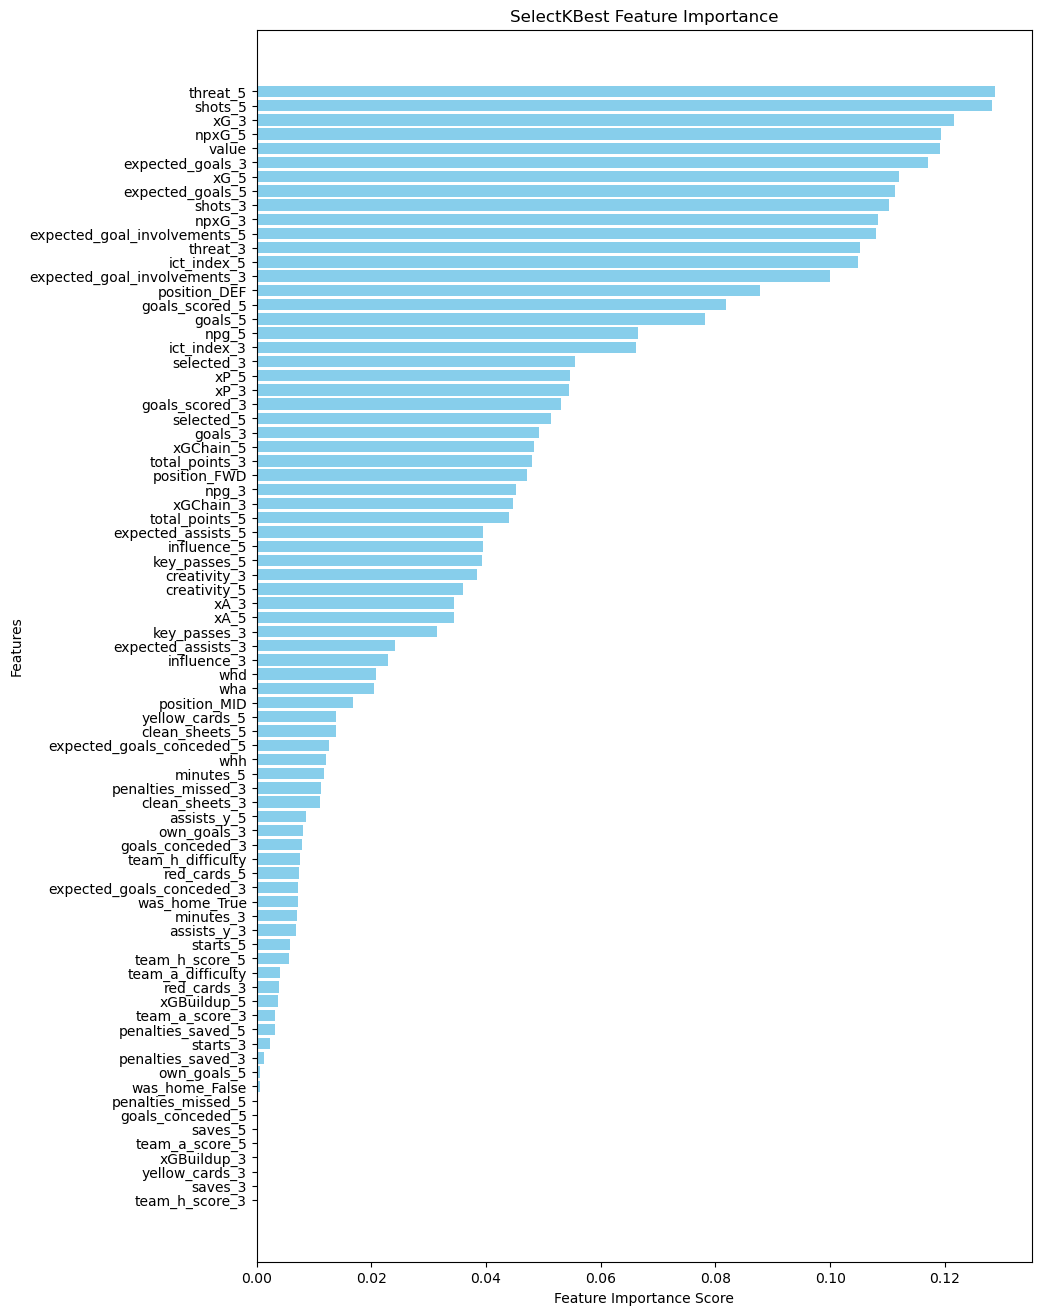

In [858]:
# Get feature scores and names
feature_scores = selector.scores_  # Feature importance scores
feature_names = feats_.columns  # Feature names

# Sort features by importance
sorted_indices = np.argsort(feature_scores)[::-1]  # Sort descending
sorted_features = np.array(feature_names)[sorted_indices]
sorted_scores = feature_scores[sorted_indices]

# Plot feature importance
plt.figure(figsize=(10, 16))
plt.barh(sorted_features, sorted_scores, color='skyblue')
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("SelectKBest Feature Importance")
plt.gca().invert_yaxis()  # Show most important feature on top
plt.show()

### Linear Model


In [859]:

lin_reg_KBest = Linear_regression(feats_train_KBest, feats_test_KBest, xg_train_KBest.values.ravel(), xg_test_KBest.values.ravel())


# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(lin_reg_KBest = [lin_reg_KBest['train_MAE'], lin_reg_KBest['test_MAE'], lin_reg_KBest['train_RMSE'], lin_reg_KBest['test_RMSE'], lin_reg_KBest['cv_rmse'], lin_reg_KBest['R2_train'], lin_reg_KBest['R2_test']])

evaluation_stats

Training set RMSE: 0.8916185027091791
Test set RMSE: 0.8788234552063475
Training set R2: 0.21699017340357185
Test set R2: 0.17726070277078776


,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM,VarT_lin_reg,VarT_dt_reg,VarT_rf_reg,VarT_xgb_reg,lin_reg_KBest
train_MAE,0.516671,3.158588e-17,0.445971,0.490059,0.490059,0.545233,3.254189e-17,0.447282,0.494053,0.498303,0.518709,6.693219e-19,0.446287,0.490059,0.530399
test_MAE,0.515621,6.512310e-01,0.513642,0.511282,0.511282,0.534540,6.780511e-01,0.514367,0.514809,0.512716,0.518336,6.602664e-01,0.513976,0.511281,0.522371
train_RMSE,0.867664,6.015365e-17,0.715031,0.801809,0.801809,0.905627,6.102949e-17,0.718174,0.810789,0.816534,0.870151,1.397837e-17,0.715580,0.801809,0.891619
test_RMSE,0.873449,1.212852e+00,0.877233,0.864707,0.864707,0.898854,1.238312e+00,0.878753,0.868901,0.867860,0.878322,1.213380e+00,0.879595,0.864707,0.878823
cv_rmse,0.881455,1.286536e+00,0.893087,0.879876,0.879876,0.906434,1.250642e+00,0.891802,0.882911,0.888489,0.882367,1.272291e+00,0.893179,0.879937,0.892546
R2_train,0.258497,1.000000e+00,0.496431,0.366786,0.366786,0.192193,1.000000e+00,0.491994,0.352522,0.343314,0.254241,1.000000e+00,0.495657,0.366786,0.216990
R2_test,0.187294,-5.670197e-01,0.180236,0.203479,0.203479,0.139329,-6.334997e-01,0.177393,0.195735,0.197661,0.178200,-5.683838e-01,0.175816,0.203479,0.177261


### Decision Tree


In [860]:
dt_reg_KBest = DecisionTreeRegression(feats_train_KBest, feats_test_KBest, xg_train_KBest.values.ravel(), xg_test_KBest.values.ravel())

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(dt_reg_KBest = [dt_reg_KBest['train_MAE'], dt_reg_KBest['test_MAE'], dt_reg_KBest['train_RMSE'], dt_reg_KBest['test_RMSE'], dt_reg_KBest['cv_rmse'], dt_reg_KBest['R2_train'], dt_reg_KBest['R2_test']])

evaluation_stats



,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM,VarT_lin_reg,VarT_dt_reg,VarT_rf_reg,VarT_xgb_reg,lin_reg_KBest,dt_reg_KBest
train_MAE,0.516671,3.158588e-17,0.445971,0.490059,0.490059,0.545233,3.254189e-17,0.447282,0.494053,0.498303,0.518709,6.693219e-19,0.446287,0.490059,0.530399,0.035259
test_MAE,0.515621,6.512310e-01,0.513642,0.511282,0.511282,0.534540,6.780511e-01,0.514367,0.514809,0.512716,0.518336,6.602664e-01,0.513976,0.511281,0.522371,0.651402
train_RMSE,0.867664,6.015365e-17,0.715031,0.801809,0.801809,0.905627,6.102949e-17,0.718174,0.810789,0.816534,0.870151,1.397837e-17,0.715580,0.801809,0.891619,0.176764
test_RMSE,0.873449,1.212852e+00,0.877233,0.864707,0.864707,0.898854,1.238312e+00,0.878753,0.868901,0.867860,0.878322,1.213380e+00,0.879595,0.864707,0.878823,1.199008
cv_rmse,0.881455,1.286536e+00,0.893087,0.879876,0.879876,0.906434,1.250642e+00,0.891802,0.882911,0.888489,0.882367,1.272291e+00,0.893179,0.879937,0.892546,1.273612
R2_train,0.258497,1.000000e+00,0.496431,0.366786,0.366786,0.192193,1.000000e+00,0.491994,0.352522,0.343314,0.254241,1.000000e+00,0.495657,0.366786,0.216990,0.969225
R2_test,0.187294,-5.670197e-01,0.180236,0.203479,0.203479,0.139329,-6.334997e-01,0.177393,0.195735,0.197661,0.178200,-5.683838e-01,0.175816,0.203479,0.177261,-0.531451


### RandomForest


In [861]:
hyperparameters = {"criterion": 'friedman_mse', "max_depth": 8, "max_features": 'sqrt', "n_estimators": 20}
rf_reg_KBest = RandomForestRegression(feats_train_KBest, feats_test_KBest, xg_train_KBest.values.ravel(), xg_test_KBest.values.ravel(), hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(rf_reg_KBest = [rf_reg_KBest['train_MAE'], rf_reg_KBest['test_MAE'], rf_reg_KBest['train_RMSE'], rf_reg_KBest['test_RMSE'], rf_reg_KBest['cv_rmse'], rf_reg_KBest['R2_train'], rf_reg_KBest['R2_test']])

evaluation_stats

,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM,VarT_lin_reg,VarT_dt_reg,VarT_rf_reg,VarT_xgb_reg,lin_reg_KBest,dt_reg_KBest,rf_reg_KBest
train_MAE,0.516671,3.158588e-17,0.445971,0.490059,0.490059,0.545233,3.254189e-17,0.447282,0.494053,0.498303,0.518709,6.693219e-19,0.446287,0.490059,0.530399,0.035259,0.471624
test_MAE,0.515621,6.512310e-01,0.513642,0.511282,0.511282,0.534540,6.780511e-01,0.514367,0.514809,0.512716,0.518336,6.602664e-01,0.513976,0.511281,0.522371,0.651402,0.514220
train_RMSE,0.867664,6.015365e-17,0.715031,0.801809,0.801809,0.905627,6.102949e-17,0.718174,0.810789,0.816534,0.870151,1.397837e-17,0.715580,0.801809,0.891619,0.176764,0.772170
test_RMSE,0.873449,1.212852e+00,0.877233,0.864707,0.864707,0.898854,1.238312e+00,0.878753,0.868901,0.867860,0.878322,1.213380e+00,0.879595,0.864707,0.878823,1.199008,0.874086
cv_rmse,0.881455,1.286536e+00,0.893087,0.879876,0.879876,0.906434,1.250642e+00,0.891802,0.882911,0.888489,0.882367,1.272291e+00,0.893179,0.879937,0.892546,1.273612,0.906842
R2_train,0.258497,1.000000e+00,0.496431,0.366786,0.366786,0.192193,1.000000e+00,0.491994,0.352522,0.343314,0.254241,1.000000e+00,0.495657,0.366786,0.216990,0.969225,0.412734
R2_test,0.187294,-5.670197e-01,0.180236,0.203479,0.203479,0.139329,-6.334997e-01,0.177393,0.195735,0.197661,0.178200,-5.683838e-01,0.175816,0.203479,0.177261,-0.531451,0.186107


### XgBoost


In [862]:
hyperparameters = {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150}
xgb_reg_KBest = XGBoostRegression(feats_train_KBest, feats_test_KBest, xg_train_KBest.values.ravel(), xg_test_KBest.values.ravel(), hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(xgb_reg_KBest = [xgb_reg_KBest['train_MAE'], xgb_reg_KBest['test_MAE'], xgb_reg_KBest['train_RMSE'], xgb_reg_KBest['test_RMSE'], xgb_reg_KBest['cv_rmse'], xgb_reg_KBest['R2_train'], xgb_reg_KBest['R2_test']])
evaluation_stats

,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM,VarT_lin_reg,VarT_dt_reg,VarT_rf_reg,VarT_xgb_reg,lin_reg_KBest,dt_reg_KBest,rf_reg_KBest,xgb_reg_KBest
train_MAE,0.516671,3.158588e-17,0.445971,0.490059,0.490059,0.545233,3.254189e-17,0.447282,0.494053,0.498303,0.518709,6.693219e-19,0.446287,0.490059,0.530399,0.035259,0.471624,0.515848
test_MAE,0.515621,6.512310e-01,0.513642,0.511282,0.511282,0.534540,6.780511e-01,0.514367,0.514809,0.512716,0.518336,6.602664e-01,0.513976,0.511281,0.522371,0.651402,0.514220,0.518641
train_RMSE,0.867664,6.015365e-17,0.715031,0.801809,0.801809,0.905627,6.102949e-17,0.718174,0.810789,0.816534,0.870151,1.397837e-17,0.715580,0.801809,0.891619,0.176764,0.772170,0.852879
test_RMSE,0.873449,1.212852e+00,0.877233,0.864707,0.864707,0.898854,1.238312e+00,0.878753,0.868901,0.867860,0.878322,1.213380e+00,0.879595,0.864707,0.878823,1.199008,0.874086,0.871607
cv_rmse,0.881455,1.286536e+00,0.893087,0.879876,0.879876,0.906434,1.250642e+00,0.891802,0.882911,0.888489,0.882367,1.272291e+00,0.893179,0.879937,0.892546,1.273612,0.906842,0.895620
R2_train,0.258497,1.000000e+00,0.496431,0.366786,0.366786,0.192193,1.000000e+00,0.491994,0.352522,0.343314,0.254241,1.000000e+00,0.495657,0.366786,0.216990,0.969225,0.412734,0.283553
R2_test,0.187294,-5.670197e-01,0.180236,0.203479,0.203479,0.139329,-6.334997e-01,0.177393,0.195735,0.197661,0.178200,-5.683838e-01,0.175816,0.203479,0.177261,-0.531451,0.186107,0.190717


### AdaBoost


In [863]:
hyperparameters = {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150}
ada_reg_KBest = XGBoostRegression(feats_train_KBest, feats_test_KBest, xg_train_KBest.values.ravel(), xg_test_KBest.values.ravel(), hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(ada_reg_KBest = [ada_reg_KBest['train_MAE'], ada_reg_KBest['test_MAE'], ada_reg_KBest['train_RMSE'], ada_reg_KBest['test_RMSE'], ada_reg_KBest['cv_rmse'], ada_reg_KBest['R2_train'], ada_reg_KBest['R2_test']])
evaluation_stats

,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM,VarT_lin_reg,VarT_dt_reg,VarT_rf_reg,VarT_xgb_reg,lin_reg_KBest,dt_reg_KBest,rf_reg_KBest,xgb_reg_KBest,ada_reg_KBest
train_MAE,0.516671,3.158588e-17,0.445971,0.490059,0.490059,0.545233,3.254189e-17,0.447282,0.494053,0.498303,0.518709,6.693219e-19,0.446287,0.490059,0.530399,0.035259,0.471624,0.515848,0.515848
test_MAE,0.515621,6.512310e-01,0.513642,0.511282,0.511282,0.534540,6.780511e-01,0.514367,0.514809,0.512716,0.518336,6.602664e-01,0.513976,0.511281,0.522371,0.651402,0.514220,0.518641,0.518641
train_RMSE,0.867664,6.015365e-17,0.715031,0.801809,0.801809,0.905627,6.102949e-17,0.718174,0.810789,0.816534,0.870151,1.397837e-17,0.715580,0.801809,0.891619,0.176764,0.772170,0.852879,0.852879
test_RMSE,0.873449,1.212852e+00,0.877233,0.864707,0.864707,0.898854,1.238312e+00,0.878753,0.868901,0.867860,0.878322,1.213380e+00,0.879595,0.864707,0.878823,1.199008,0.874086,0.871607,0.871607
cv_rmse,0.881455,1.286536e+00,0.893087,0.879876,0.879876,0.906434,1.250642e+00,0.891802,0.882911,0.888489,0.882367,1.272291e+00,0.893179,0.879937,0.892546,1.273612,0.906842,0.895620,0.895620
R2_train,0.258497,1.000000e+00,0.496431,0.366786,0.366786,0.192193,1.000000e+00,0.491994,0.352522,0.343314,0.254241,1.000000e+00,0.495657,0.366786,0.216990,0.969225,0.412734,0.283553,0.283553
R2_test,0.187294,-5.670197e-01,0.180236,0.203479,0.203479,0.139329,-6.334997e-01,0.177393,0.195735,0.197661,0.178200,-5.683838e-01,0.175816,0.203479,0.177261,-0.531451,0.186107,0.190717,0.190717


# Hyperparameter Tunning

Picked XGBoost


In [879]:

from sklearn.model_selection import RandomizedSearchCV
# feats_train, feats_test, xg_train, xg_test
# Define XGBoost model
xgb_model = xgb(objective='reg:squarederror', random_state=42)

# Define hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth': [3, 5, 7, 10],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.3, 0.5, 1.0],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1, 10],
    'reg_lambda': [0, 0.01, 0.1, 1, 10]
}

# Perform Randomized Search
random_search = RandomizedSearchCV(
    xgb_model, param_distributions=param_dist,
    n_iter=50, scoring='neg_mean_absolute_error',
    cv=5, verbose=2, random_state=42, n_jobs=-1
)

# Fit to training data
random_search.fit(feats_train, xg_train.values.ravel())

# Best parameters
print("Best Parameters:", random_search.best_params_)

# Best model
best_xgb = random_search.best_estimator_


Fitting 5 folds for each of 50 candidates, totalling 250 fits


KeyboardInterrupt: 

In [819]:
random_search.best_params_

{'subsample': 0.8,
 'reg_lambda': 10,
 'reg_alpha': 0.01,
 'n_estimators': 200,
 'min_child_weight': 5,
 'max_depth': 3,
 'learning_rate': 0.05,
 'gamma': 0.1,
 'colsample_bytree': 0.8}

In [790]:
from sklearn.model_selection import GridSearchCV

# Define refined grid based on RandomizedSearchCV results
param_grid = {
    'n_estimators': [150, 200, 250],
    'learning_rate': [0.02, 0.03, 0.05, 0.06, 0.07],
    'max_depth': [2, 3, 4, 5],
    'min_child_weight': [4, 5, 6],
    'gamma': [0.025,0.05, 0.075, 0.1, 0.125,0.15, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0.01],
    'reg_lambda': [0, 3, 6, 9, 10]
}

grid_search = GridSearchCV(
    xgb_model, param_grid, scoring='neg_mean_absolute_error',
    cv=5, verbose=2, n_jobs=-1
)

grid_search.fit(feats_train, xg_train.values.ravel())

print("Best Grid Parameters:", grid_search.best_params_)

# Best model
best_xgb = grid_search.best_estimator_


KeyboardInterrupt: 

In [880]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Make predictions
xg_pred = best_xgb.predict(feats_test)

# Evaluate performance
mae = mean_absolute_error(xg_test, xg_pred)
rmse = np.sqrt(mean_squared_error(xg_test, xg_pred))
r2 = r2_score(xg_test, xg_pred)

print(f"Test MAE: {mae}")
print(f"Test RMSE: {rmse}")
print(f"Test R² Score: {r2}")

ValueError: feature_names mismatch: ['team_h_difficulty', 'team_a_difficulty', 'value', 'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3', 'xP_3', 'selected_3', 'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5', 'team_a_score_5', 'team_h_score_

In [869]:
xg_test.min(), xg_pred.min(), '===> ', xg_test.max(), xg_pred.max()

(xG   -0.513213
 dtype: float64,
 -0.44399774,
 '===> ',
 xG    9.600877
 dtype: float64,
 3.5216093)

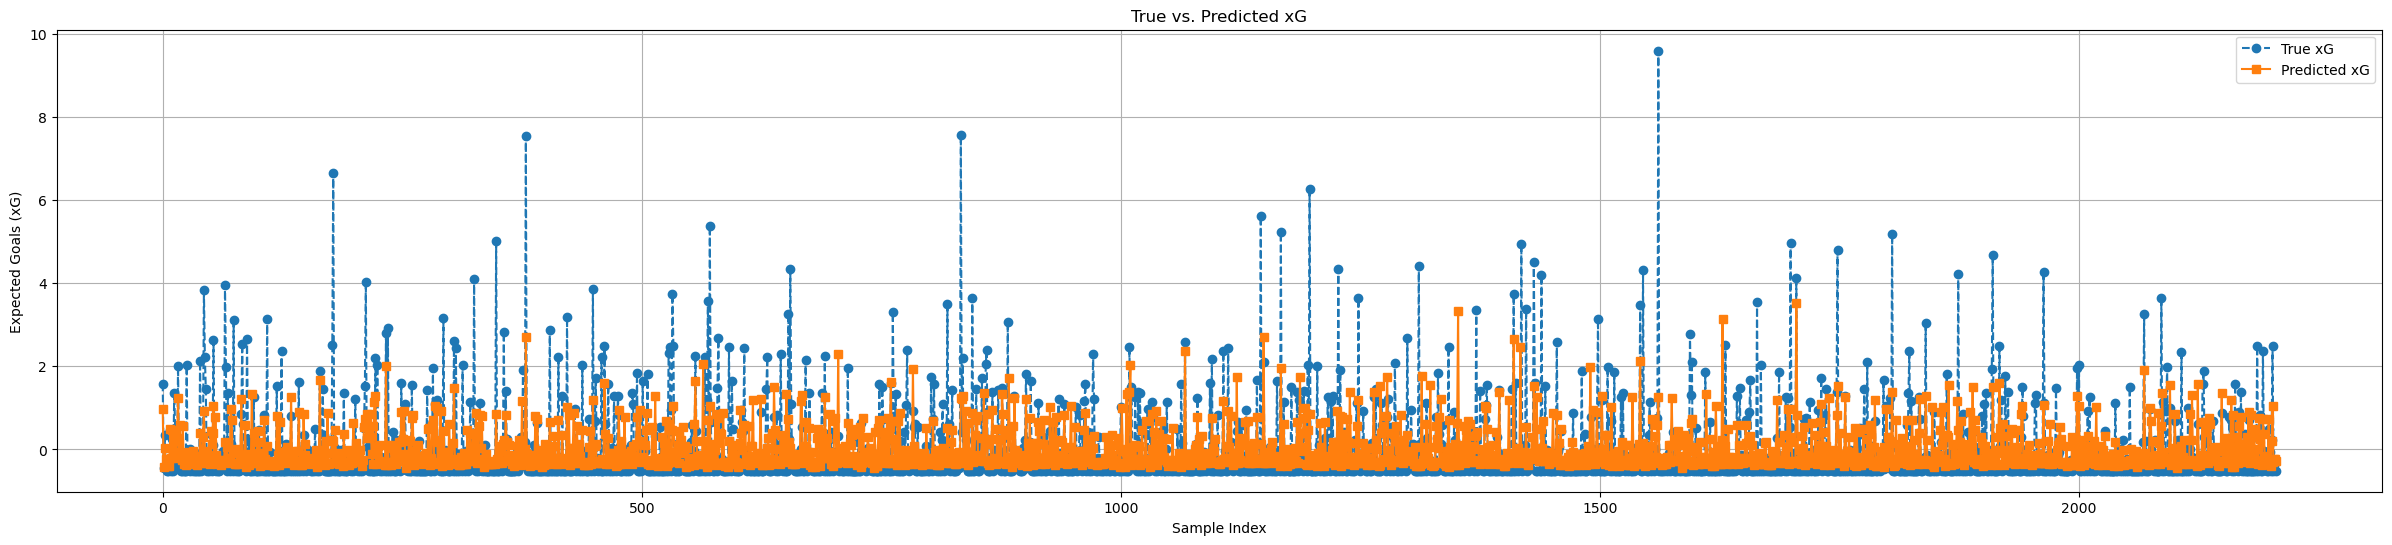

In [870]:
import matplotlib.pyplot as plt
import seaborn as sns


# Plot
plt.figure(figsize=(30, 6))
plt.plot(xg_test.values, label="True xG", marker='o', linestyle='dashed')  # Convert DataFrame to array
plt.plot(xg_pred, label="Predicted xG", marker='s', linestyle='solid')

# Labels and Title
plt.xlabel("Sample Index")
plt.ylabel("Expected Goals (xG)")
plt.title("True vs. Predicted xG")
plt.legend()
plt.grid(True)

# Show plot
plt.show()
